# Neural Network Foundations for Biological Prediction

## Objective

This notebook implements neural network fundamentals starting from a **single neuron model**, building intuition toward **multilayer architectures (MLPs)**.

The goal is to understand how these models can be applied to:

- Biological classification tasks  
- Prediction of molecular or experimental outcomes  
- Learning non-linear relationships in biological systems  

💡 These principles form the foundation of AI-driven approaches in biotech and drug discovery.

## Problem Framing

Biological prediction tasks can be formulated as supervised learning problems:

- **Inputs:** biological features (e.g. molecular descriptors, experimental variables)  
- **Outputs:** target variables (classification or regression)  

This notebook starts from a minimal model (single neuron) to build intuition toward more complex architectures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Reproducibility
np.random.seed(42)

# Create results directory if it does not exist
RESULTS_PATH = "../results"
os.makedirs(RESULTS_PATH, exist_ok=True)

In [2]:
# Initialization
def initialize_neuron(input_size):
    weights = np.random.rand(input_size)
    bias = np.random.rand(1)
    return weights, bias

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def step(x):
    return np.where(x >= 0, 1, 0)
# Forward pass
def forward_pass(inputs, weights, bias, activation="sigmoid"):
    inputs = np.array(inputs)
    
    z = np.dot(inputs, weights) + bias
    
    if activation == "sigmoid":
        return sigmoid(z)
    elif activation == "relu":
        return relu(z)
    elif activation == "tanh":
        return tanh(z)
    elif activation == "step":
        return step(z)
    else:
        raise ValueError(f"Unsupported activation function: {activation}")

## 1. Single Neuron Behavior (1D Analysis)

We analyze how a single neuron responds to input values in the range [0, 1], using different activation functions.

This helps understand how the model transforms input signals into outputs.

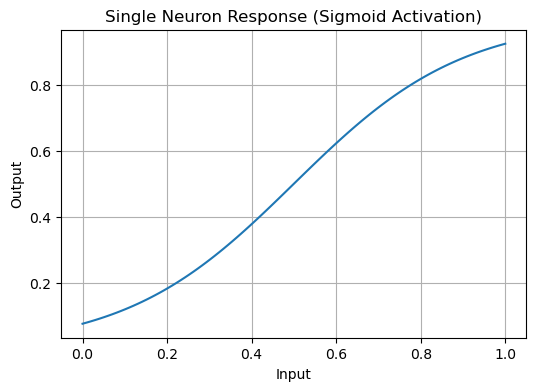

In [5]:
# Generate input data
x_range = np.linspace(0, 1, 100)

# Model parameters
weights = np.array([5])
bias = np.array([-2.5])

# Compute outputs
outputs = [
    forward_pass([x], weights, bias, activation="sigmoid")[0]
    for x in x_range
]

# Plot results
plt.figure(figsize=(6, 4))
plt.plot(x_range, outputs)
plt.title("Single Neuron Response (Sigmoid Activation)")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()

# Save figure
plt.savefig(f"{RESULTS_PATH}/neuron_1d_sigmoid.png")

plt.show()

## Activation Function Comparison

We compare different activation functions to understand how they transform input signals into outputs.

This is critical for selecting appropriate models in machine learning pipelines, especially in biological data modeling where non-linear relationships are common.

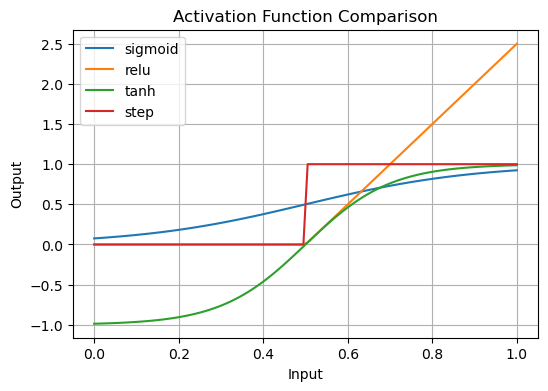

In [8]:
# Activation functions to compare
activations = ["sigmoid", "relu", "tanh", "step"]

plt.figure(figsize=(6, 4))

for act in activations:
    outputs = [
        forward_pass([x], weights, bias, activation=act)[0]
        for x in x_range
    ]
    plt.plot(x_range, outputs, label=act)

plt.legend()
plt.title("Activation Function Comparison")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()

# Save figure
plt.savefig(f"{RESULTS_PATH}/activation_functions_comparison.png")

plt.show()

## Interpretation

- **Sigmoid:** Produces a smooth transition between 0 and 1, making it suitable for probabilistic outputs in classification tasks.
- **ReLU:** Introduces sparsity and computational efficiency, widely used in deep learning models.
- **Tanh:** Similar to sigmoid but centered around zero, often improving convergence during training.
- **Step function:** Produces binary outputs, useful for conceptual understanding but not suitable for gradient-based optimization.

### Key Insight

Activation functions define the **non-linear behavior** of neural networks.

In biological systems, where relationships are rarely linear, choosing the right activation function is essential for:

- Capturing complex patterns  
- Improving model performance  
- Enabling deep learning architectures  

These concepts directly translate to real-world applications such as:

- Drug response prediction  
- Molecular property modeling  
- Genomic sequence analysis  


##2. Decision Boundary Analysis (2D Input Space)

We analyze the behavior of a single neuron with **two input features**, simulating a simplified biological prediction task.

This allows visualization of how the model partitions the input space into different output regions.

💡 In real applications, these inputs could represent:
- Molecular descriptors  
- Experimental measurements  
- Biological features  

The neuron defines a **decision boundary**, which determines classification behavior.

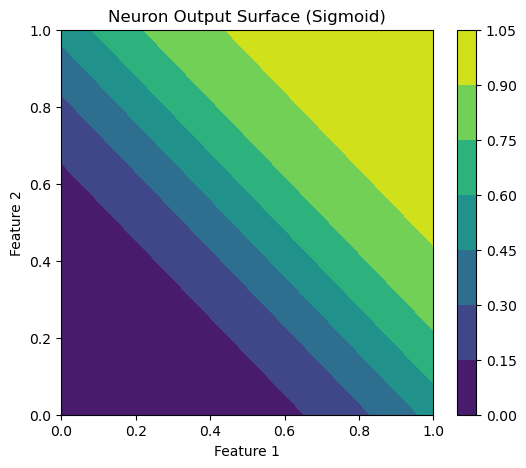

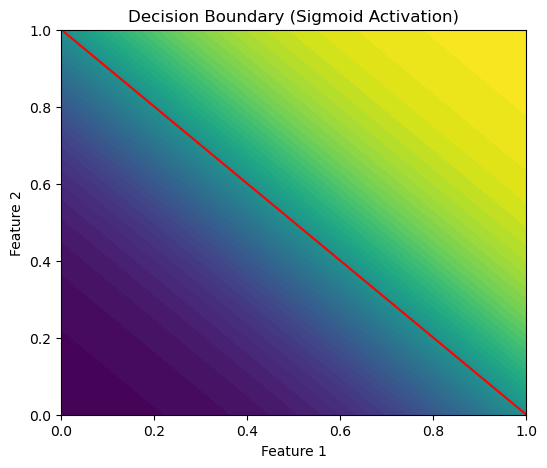

In [9]:
# Generate 2D input grid
x1 = np.linspace(0, 1, 100)
x2 = np.linspace(0, 1, 100)

X1, X2 = np.meshgrid(x1, x2)

# Model parameters
weights = np.array([5, 5])
bias = np.array([-5])

# Compute outputs
Z = np.array([
    forward_pass([a, b], weights, bias, activation="sigmoid")[0]
    for a, b in zip(X1.flatten(), X2.flatten())
])

Z = Z.reshape(X1.shape)

# --- Heatmap ---
plt.figure(figsize=(6, 5))
plt.contourf(X1, X2, Z)
plt.colorbar()
plt.title("Neuron Output Surface (Sigmoid)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.savefig(f"{RESULTS_PATH}/neuron_2d_sigmoid.png")
plt.show()

# --- Decision boundary ---
plt.figure(figsize=(6, 5))
plt.contourf(X1, X2, Z, levels=50)
plt.contour(X1, X2, Z, levels=[0.5], colors='red')

plt.title("Decision Boundary (Sigmoid Activation)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.savefig(f"{RESULTS_PATH}/neuron_2d_boundary.png")
plt.show()

### Key Insights

- The neuron defines a **linear decision boundary** in the input space.  
- This boundary separates regions with different predicted outputs.  
- The model behaves as a **linear classifier**.  

**Interpretation:**
- Weights control the **orientation** of the boundary  
- Bias controls its **position**  

💡 Industry relevance:
This is the foundation of:
- Binary classification models  
- Early-stage predictive models in biotech  
- Baseline models before applying deep learning  

⚠️ Limitation:
A single neuron cannot capture complex non-linear relationships, which motivates the use of **multilayer neural networks (MLPs)**.

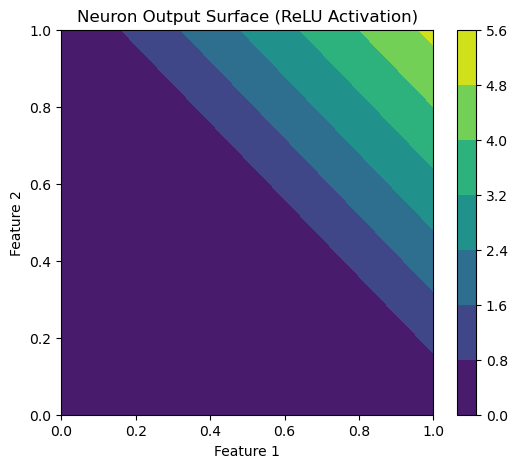

In [10]:
# Compute outputs using ReLU activation
Z = np.array([
    forward_pass([a, b], weights, bias, activation="relu")[0]
    for a, b in zip(X1.flatten(), X2.flatten())
])

Z = Z.reshape(X1.shape)

# Plot ReLU response
plt.figure(figsize=(6, 5))
plt.contourf(X1, X2, Z)
plt.colorbar()

plt.title("Neuron Output Surface (ReLU Activation)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.savefig(f"{RESULTS_PATH}/neuron_2d_relu.png")
plt.show()

### ReLU Behavior

Unlike sigmoid, ReLU introduces **piecewise linear behavior**:

- Outputs are **zero for negative inputs**
- Outputs grow linearly for positive inputs

💡 Interpretation:
ReLU creates **sparse activation regions**, which is critical for deep learning models.

⚠️ Limitation (single neuron):
Even with ReLU, the model still defines a **linear decision boundary**.

## 3. High-Dimensional Behavior (3D Input Space)

We extend the analysis to **three input features**, simulating more realistic biological scenarios.

Since direct visualization of decision boundaries becomes difficult in higher dimensions, we analyze model behavior through sampled data.

💡 Example interpretation:
Each dimension could represent:
- Molecular properties  
- Experimental conditions  
- Biological measurements  

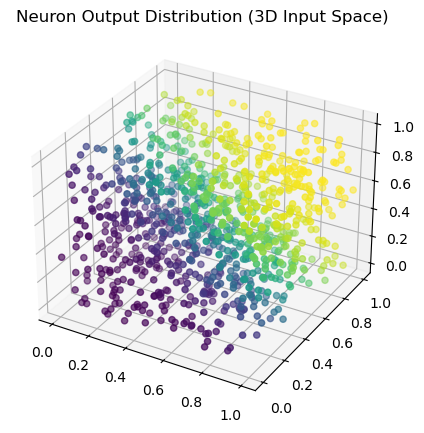

In [16]:
# Generate random 3D inputs
inputs = np.random.rand(1000, 3)

# Model parameters
weights = np.array([5, 5, 5])
bias = np.array([-7.5])

# Compute outputs
outputs = np.array([
    forward_pass(i, weights, bias, activation="sigmoid")[0]
    for i in inputs
])

# 3D visualization
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    inputs[:, 0],
    inputs[:, 1],
    inputs[:, 2],
    c=outputs
)

plt.title("Neuron Output Distribution (3D Input Space)")

plt.savefig(f"{RESULTS_PATH}/neuron_3d_scatter.png")
plt.show()

### Key Insights

- In 3D, the neuron defines a **plane** separating the input space into regions.  
- This plane is determined by the **linear combination of inputs, weights, and bias**.  

This generalizes to higher dimensions:

➡️ A single neuron defines a **hyperplane in n-dimensional space**  

---

### Model Interpretation

- The neuron behaves as a **linear classifier**, regardless of dimensionality  
- Increasing dimensions increases complexity of the data  
- But **does not increase model expressiveness**

---

### Critical Limitation

A single neuron cannot model **non-linear relationships**, even in high dimensions.

💡 Industry implication:
Real-world biological systems are highly non-linear →  
This motivates the use of:

- Multilayer Perceptrons (MLPs)  
- Deep Learning architectures  
- Non-linear feature transformations  

## 4. Binary Classification with a Single Neuron

We analyze how a single neuron can model **binary decision rules**, using logical operations as simplified examples.

These operations can be interpreted as **toy classification problems**, where:

- Inputs → feature vectors  
- Output → binary class (0 or 1)  

💡 This is directly related to:
- Binary classification tasks  
- Early-stage predictive models  
- Decision boundaries in ML systems  


In [17]:
# Define input space
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# AND logic
weights = np.array([1, 1])
bias = np.array([-1.5])

outputs = [forward_pass(i, weights, bias, activation="step")[0] for i in inputs]

print("AND Gate:")
for i, o in zip(inputs, outputs):
    print(f"Input: {i} -> Output: {o}")

AND Gate:
Input: [0 0] -> Output: 0
Input: [0 1] -> Output: 0
Input: [1 0] -> Output: 0
Input: [1 1] -> Output: 1


### AND Operation

The neuron activates only when **both inputs are 1**.

💡 Interpretation:
This corresponds to a **strict decision boundary**, where both features must contribute positively.

In [18]:
# OR logic
weights = np.array([1, 1])
bias = np.array([-0.5])

outputs = [forward_pass(i, weights, bias, activation="step")[0] for i in inputs]

print("\nOR Gate:")
for i, o in zip(inputs, outputs):
    print(f"Input: {i} -> Output: {o}")


OR Gate:
Input: [0 0] -> Output: 0
Input: [0 1] -> Output: 1
Input: [1 0] -> Output: 1
Input: [1 1] -> Output: 1


### OR Operation

The neuron activates when **at least one input is 1**.

💡 Interpretation:
The decision boundary is more permissive compared to AND.

In [19]:
# NOT logic
inputs_not = np.array([[0], [1]])

weights = np.array([-1])
bias = np.array([0.5])

outputs = [forward_pass(i, weights, bias, activation="step")[0] for i in inputs_not]

print("\nNOT Gate:")
for i, o in zip(inputs_not, outputs):
    print(f"Input: {i} -> Output: {o}")


NOT Gate:
Input: [0] -> Output: 1
Input: [1] -> Output: 0


### NOT Operation

The neuron inverts the input signal.

💡 Interpretation:
This demonstrates how weights can encode **negative relationships between features and outputs**.

In [20]:
# Sigmoid approximation of AND
outputs = [
    forward_pass(i, np.array([1, 1]), np.array([-1.5]), activation="sigmoid")[0]
    for i in inputs
]

print("\nSigmoid Approximation (AND):")
for i, o in zip(inputs, outputs):
    print(f"Input: {i} -> Output: {o:.4f}")


Sigmoid Approximation (AND):
Input: [0 0] -> Output: 0.1824
Input: [0 1] -> Output: 0.3775
Input: [1 0] -> Output: 0.3775
Input: [1 1] -> Output: 0.6225


### Activation Function Impact

- **Step function → exact binary outputs (0 or 1)**  
- **Sigmoid → smooth probabilistic outputs (0–1 range)**  
- **ReLU → continuous, non-binary outputs**  

💡 Key insight:
Using sigmoid transforms the neuron into a **probabilistic classifier**, rather than a strict logical system.

---

### Industry Perspective

This section reflects the foundation of:

- Logistic regression  
- Binary classification models  
- Decision-making systems in ML pipelines  

⚠️ Limitation:
A single neuron can only model **linearly separable problems**.

This leads to a critical limitation:

❌ Cannot solve XOR  
❌ Cannot capture complex biological interactions  

➡️ This motivates the need for:
- Multilayer neural networks  
- Non-linear feature transformations  

## 5. Gradient-Based Learning

We now move from model definition to **model training**.

This section introduces:
- Loss functions  
- Gradient computation  
- Parameter updates  

💡 This is the foundation of how machine learning models **learn from data**.

We frame the problem as **binary classification**, using:
- Sigmoid activation → probabilistic output  
- Binary Cross-Entropy → optimization objective  

In [21]:
# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Binary Cross-Entropy Loss
def binary_cross_entropy_loss(y_pred, y_true):
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Gradient computation (simplified for sigmoid + BCE)
def compute_gradients(inputs, weights, bias, y_true):
    z = np.dot(weights, inputs) + bias
    y_pred = sigmoid(z)

    loss = binary_cross_entropy_loss(y_pred, y_true)

    # Key simplification:
    error = y_pred - y_true

    d_weights = error * inputs
    d_bias = error

    return d_weights, d_bias, loss, y_pred

In [23]:
# Dataset (AND problem)
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_true = np.array([0, 0, 0, 1])

# Parameters (near optimal)
weights = np.array([5, 3])
bias = np.array([-7])

# Evaluate gradients
for x, y in zip(inputs, y_true):
    dw, db, loss, y_pred = compute_gradients(x, weights, bias, y)

    print(f"Input: {x}")
    print(f"y_true: {y}, y_pred: {y_pred.item():.4f}")
    print(f"Loss: {loss.item():.4f}")
    print(f"Gradients -> dw: {dw}, db: {db}")
    print("-"*40)


Input: [0 0]
y_true: 0, y_pred: 0.0009
Loss: 0.0009
Gradients -> dw: [0. 0.], db: [0.00091105]
----------------------------------------
Input: [0 1]
y_true: 0, y_pred: 0.0180
Loss: 0.0181
Gradients -> dw: [0.         0.01798621], db: [0.01798621]
----------------------------------------
Input: [1 0]
y_true: 0, y_pred: 0.1192
Loss: 0.1269
Gradients -> dw: [0.11920292 0.        ], db: [0.11920292]
----------------------------------------
Input: [1 1]
y_true: 1, y_pred: 0.7311
Loss: 0.3133
Gradients -> dw: [-0.26894142 -0.26894142], db: [-0.26894142]
----------------------------------------


### Gradient Analysis

- When predictions are **accurate**, the loss is low and gradients are close to zero  
- When predictions are **incorrect**, the loss increases and gradients become larger  

💡 Key insight:  
Gradients encode both the **magnitude** and **direction** of parameter updates.

---

### Interpretation

- Small gradients → model is near optimal  
- Large gradients → model requires significant updates  

In particular:
- Misclassified examples generate larger gradients  
- Correct predictions contribute minimal updates  

---

### Key Observation from Results

The sample **[1, 1]** (positive class) produces the largest gradient.

💡 Interpretation:
The model prioritizes correcting the most important and most erroneous predictions.

---

### Industry Perspective

This behavior underlies:

- Gradient Descent optimization  
- Neural network training  
- Loss minimization in ML pipelines  

💡 Practical implication:  
Models automatically focus on **hard examples**, improving performance where it matters most.

In [25]:
# Random initialization
weights = np.random.rand(2)
bias = np.random.rand(1)

print("Initial weights:", weights)
print("Initial bias:", bias)
print("="*40)

# Evaluate gradients
for x, y in zip(inputs, y_true):
    dw, db, loss, y_pred = compute_gradients(x, weights, bias, y)

    print(f"Input: {x}")
    print(f"y_true: {y}, y_pred: {y_pred.item():.4f}")
    print(f"Loss: {loss.item():.4f}")
    print(f"Gradients -> dw: {dw}, db: {db}")
    print("-"*40)

Initial weights: [0.6248741  0.57174598]
Initial bias: [0.83283038]
Input: [0 0]
y_true: 0, y_pred: 0.6970
Loss: 1.1939
Gradients -> dw: [0. 0.], db: [0.69695307]
----------------------------------------
Input: [0 1]
y_true: 0, y_pred: 0.8029
Loss: 1.6241
Gradients -> dw: [0.         0.80290908], db: [0.80290908]
----------------------------------------
Input: [1 0]
y_true: 0, y_pred: 0.8112
Loss: 1.6670
Gradients -> dw: [0.81118133 0.        ], db: [0.81118133]
----------------------------------------
Input: [1 1]
y_true: 1, y_pred: 0.8839
Loss: 0.1235
Gradients -> dw: [-0.11614532 -0.11614532], db: [-0.11614532]
----------------------------------------


### Random Initialization Analysis

Using randomly initialized parameters, the model produces **poor predictions** and **high loss values**, particularly for negative class examples.

#### Key Observations

- The model predicts **high probabilities (~0.7–0.8)** even when the true label is 0  
- This results in **large loss values**, indicating poor model calibration  
- Gradients are **large**, especially for misclassified examples  

#### Gradient Behavior

- Incorrect predictions → **large gradients** → strong parameter updates  
- Correct or near-correct predictions → **smaller gradients**  

Example:
- `[1,1] → y=1` is relatively well predicted → **low loss (0.12)**  
- `[0,1]` and `[1,0] → y=0` are poorly predicted → **high loss (~1.6)**  

---

### 💡 Key Insight

Random initialization places the model **far from the optimal solution**, requiring:

- Large parameter updates  
- Multiple optimization steps  
- Gradient-based learning to converge  

---

### 🧠 Industry Perspective

This behavior reflects real-world ML training:

- Models start with **uninformative parameters**
- Training is driven by **error correction via gradients**
- Hard examples dominate learning early in training  

👉 Practical implication:

Initialization + optimization strategy strongly impacts:
- Convergence speed  
- Training stability  
- Final model performance  

In [26]:
# Single training step example

inputs = np.array([1, 1])
y_true = 1

weights = np.array([0.5, -0.5])
bias = 0.0

# Before update
dW, dB, loss_before, y_pred_before = compute_gradients(inputs, weights, bias, y_true)

print("BEFORE UPDATE")
print(f"y_pred: {y_pred_before:.4f}")
print(f"loss: {loss_before:.4f}")

# Learning rate
LR = 0.1

# Parameter update
weights_new = weights - LR * dW
bias_new = bias - LR * dB

# After update
dW2, dB2, loss_after, y_pred_after = compute_gradients(inputs, weights_new, bias_new, y_true)

print("\nAFTER UPDATE")
print(f"y_pred: {y_pred_after:.4f}")
print(f"loss: {loss_after:.4f}")

BEFORE UPDATE
y_pred: 0.5000
loss: 0.6931

AFTER UPDATE
y_pred: 0.5374
loss: 0.6210


### Parameter Update via Gradient Descent

We evaluate how a single gradient update affects model performance.

#### Results

- Before update:
  - y_pred = 0.5000  
  - loss = 0.6931  

- After update:
  - y_pred = 0.5374  
  - loss = 0.6210  

---

### 🔍 Interpretation

- The prediction moves **closer to the true value (y = 1)**  
- The loss **decreases**, indicating improved model performance  

This confirms that:

👉 The gradient correctly points in the direction that **minimizes the loss function**

---

### 💡 Key Insight

Gradient descent updates parameters such that:

- Predictions become more accurate  
- Error is reduced iteratively  
- The model moves toward an optimal solution  

---

### 🧠 Industry Perspective

This simple example reflects the core mechanism behind:

- Neural network training  
- Deep learning optimization  
- Backpropagation in large-scale models  

👉 Even in complex architectures (CNNs, Transformers),  
the same principle applies:

**Parameters are updated to minimize error via gradients**

---

### ⚙️ Practical Implication

- Learning rate (LR) controls step size  
- Proper tuning is essential:
  - Too large → unstable training  
  - Too small → slow convergence  

This step illustrates the foundation of all modern ML pipelines.

### Gradient Contribution Across Samples (AND Dataset)

We analyze how each training example contributes to the gradient update.

#### Key Observations

- `[0,0]` → No contribution to weights (inputs are zero), only bias is updated  
- `[0,1]` and `[1,0]` → Partial updates (only one weight updated)  
- `[1,1]` → Full contribution to both weights  

#### Loss Behavior

- Misclassified examples → **high loss + large gradients**  
- Correct predictions → **low loss + small gradients**  

---

### 💡 Key Insight

Each sample contributes differently to the learning process:

- Gradient magnitude depends on **prediction error**
- Weight updates depend on **input values**

---

### ⚠️ Important Limitation

Gradients from individual samples can:

- Differ in magnitude  
- Point in different directions  

👉 Updating parameters using a single sample can lead to **unstable learning**

---

### 🧠 Industry Perspective

This motivates the use of:

- Batch Gradient Descent  
- Mini-batch training  

👉 Averaging gradients provides a **more stable and representative update direction**

In [28]:
# --- Dataset ---
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

# --- Initialization ---
np.random.seed(42)
weights = np.random.randn(2)
bias = np.random.randn()

# --- Hyperparameters ---
learning_rate = 0.2
epochs = 5000

# --- Tracking ---
loss_history = []

# --- Training Loop ---
for epoch in range(epochs):

    total_dW = np.zeros_like(weights)
    total_dB = 0.0
    total_loss = 0.0

    # Batch iteration
    for i in range(len(X)):
        inputs = X[i]
        target = y[i]

        dW, dB, loss, _ = compute_gradients(inputs, weights, bias, target)

        total_dW += dW
        total_dB += dB
        total_loss += loss

    # Average gradients
    avg_dW = total_dW / len(X)
    avg_dB = total_dB / len(X)
    avg_loss = total_loss / len(X)

    # Parameter update
    weights -= learning_rate * avg_dW
    bias -= learning_rate * avg_dB

    loss_history.append(avg_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} - Loss: {avg_loss:.4f}")

# --- Final Results ---
print("\nFinal Parameters:")
print("weights:", weights)
print("bias:", bias)

print("\nFinal Predictions:")
for i in range(len(X)):
    z = np.dot(weights, X[i]) + bias
    pred = sigmoid(z)
    print(f"Input {X[i]} → {pred:.4f}")

Epoch 0 - Loss: 0.9452
Epoch 500 - Loss: 0.1448
Epoch 1000 - Loss: 0.0821
Epoch 1500 - Loss: 0.0567
Epoch 2000 - Loss: 0.0432
Epoch 2500 - Loss: 0.0348
Epoch 3000 - Loss: 0.0291
Epoch 3500 - Loss: 0.0249
Epoch 4000 - Loss: 0.0218
Epoch 4500 - Loss: 0.0194

Final Parameters:
weights: [7.40862708 7.40862676]
bias: -11.285559665852547

Final Predictions:
Input [0 0] → 0.0000
Input [0 1] → 0.0203
Input [1 0] → 0.0203
Input [1 1] → 0.9716


### Training Convergence Analysis

The training process shows a **consistent and smooth decrease in loss**, indicating stable learning behavior.

#### Loss Evolution

- Initial loss: ~0.95  
- Final loss: ~0.02  

This demonstrates effective optimization using batch gradient descent.

---

### 🔍 Final Model Behavior

| Input | Prediction |
|------|-----------|
| [0,0] | ~0.0000 |
| [0,1] | ~0.0203 |
| [1,0] | ~0.0203 |
| [1,1] | ~0.9716 |

#### Interpretation

- The model correctly classifies all inputs  
- Outputs are **close to ideal binary values**  
- Slight deviations are expected due to sigmoid activation  

---

### ⚙️ Learned Parameters

- weights ≈ [7.4, 7.4]  
- bias ≈ -11.28  

#### Meaning

- Large positive weights → strong contribution from both inputs  
- Large negative bias → high activation threshold  

👉 The neuron activates only when **both inputs are high**, matching AND logic.

---

### 💡 Key Insight

The model successfully learns a **linearly separable decision boundary**, demonstrating that:

- A single neuron is sufficient for simple classification tasks  
- Gradient descent effectively minimizes prediction error  

---

### 🧠 Industry Perspective

This experiment reflects core principles of real-world ML systems:

- Iterative optimization via gradient descent  
- Batch-based training for stability  
- Convergence toward optimal parameter values  

👉 These mechanisms scale directly to:

- Deep neural networks  
- Bioinformatics models  
- Drug discovery pipelines  

---

### 🚀 Takeaway

Even complex AI systems rely on the same fundamental principle:

**Learning = iterative parameter updates guided by gradients to minimize error**

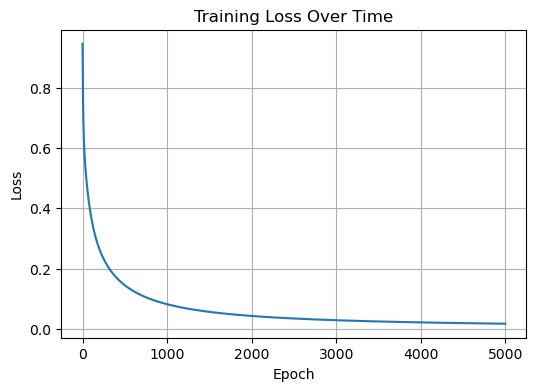

In [29]:
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.savefig(f"{RESULTS_PATH}/loss_curve.png")
plt.show()

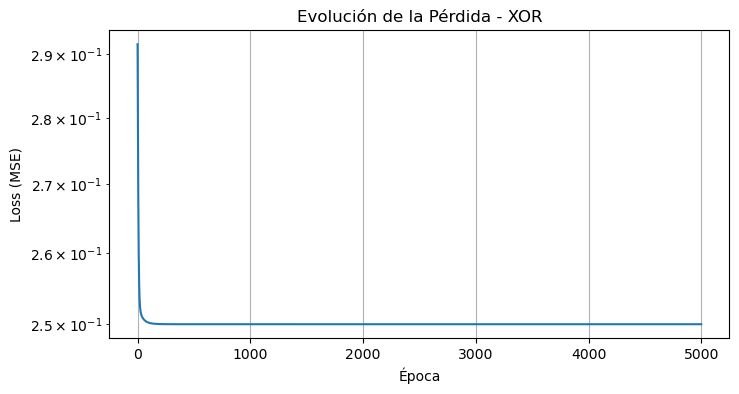

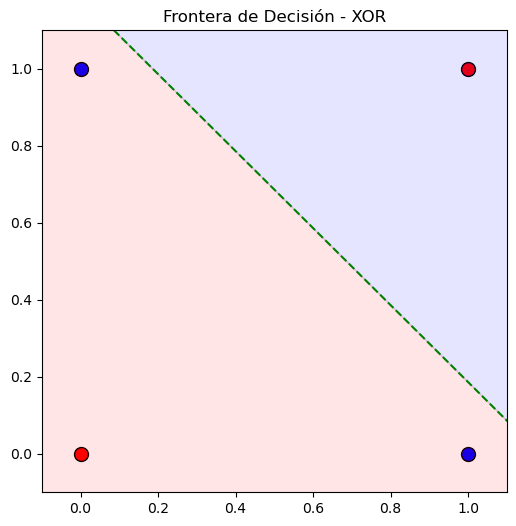

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Configuración de Carpetas ---
results_path = "../results"
if not os.path.exists(results_path):
    os.makedirs(results_path)

# --- 2. Funciones Core ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(y_pred):
    return y_pred * (1 - y_pred)

# --- 3. DATASET (COMENTAR/DESCOMENTAR SEGÚN CORRESPONDA) ---
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# OPCIÓN A: AND
#y = np.array([0, 0, 0, 1]); nombre_logica = "AND"

# OPCIÓN B: OR
#y = np.array([0, 1, 1, 1]); nombre_logica = "OR"

# OPCIÓN C: XOR (Punto d)
y = np.array([0, 1, 1, 0]); nombre_logica = "XOR"

# --- 4. Inicialización ---
np.random.seed(42)
weights = np.random.randn(2)
bias = np.random.randn()

LR_init = 0.5
epochs = 5000
loss_history = []

# --- 5. Entrenamiento (Batch Gradient Descent) ---
for epoch in range(epochs):
    LR = LR_init / (1 + epoch * 0.001) # LR Decreciente
    total_dW, total_dB, total_loss = np.zeros_like(weights), 0, 0
    
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        y_pred = sigmoid(z)
        error = y_pred - y[i]
        total_loss += error**2
        
        grad = 2 * error * sigmoid_derivative(y_pred)
        total_dW += grad * X[i]
        total_dB += grad
    
    # Actualización Batch (Promedio)
    weights -= LR * (total_dW / len(X))
    bias -= LR * (total_dB / len(X))
    loss_history.append(total_loss / len(X))

# --- 6. Visualización de Resultados ---
# Gráfico de Pérdida (Loss)
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.yscale('log')
plt.title(f"Evolución de la Pérdida - {nombre_logica}")
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.savefig(f"{results_path}/loss_{nombre_logica}.png")
plt.show()

# Gráfico de Frontera de Decisión (Muy útil para el análisis)
plt.figure(figsize=(6, 6))
for i in range(len(y)):
    plt.scatter(X[i,0], X[i,1], c=('red' if y[i]==0 else 'blue'), s=100, edgecolors='k')

x1_vals = np.linspace(-0.2, 1.2, 10)
x2_vals = -(weights[0] * x1_vals + bias) / weights[1]
plt.plot(x1_vals, x2_vals, '--g', label="Frontera")
plt.fill_between(x1_vals, x2_vals, 1.5, color='blue', alpha=0.1)
plt.fill_between(x1_vals, x2_vals, -0.5, color='red', alpha=0.1)
plt.xlim(-0.1, 1.1); plt.ylim(-0.1, 1.1)
plt.title(f"Frontera de Decisión - {nombre_logica}")
plt.savefig(f"{results_path}/frontera_{nombre_logica}.png")
plt.show()

# --- 7. Guardar Reporte TXT ---
report_path = os.path.join(results_path, f"resultados_{nombre_logica}.txt")
with open(report_path, "w") as f:
    f.write(f"=== Reporte de Entrenamiento: {nombre_logica} ===\n\n")
    f.write(f"Pesos Finales: {weights}\n")
    f.write(f"Bias Final: {bias:.4f}\n\n")
    f.write("Predicciones finales:\n")
    for i in range(len(X)):
        p = sigmoid(np.dot(X[i], weights) + bias)
        f.write(f"Entrada {X[i]} -> Prediccion: {p:.4f} (Real: {y[i]})\n")

## 🔬 Logical Functions Analysis (Single Neuron Limitations)

### a) AND Function (Sigmoid)

- Loss decreases exponentially → correct convergence  
- Weights converge to large positive values  
- Bias becomes strongly negative  

**Interpretation:**  
The neuron activates only when both inputs are high, correctly reproducing the AND behavior.

**Key insight:**  
The model learns a linear decision boundary that separates the classes.

---

### b) OR Function

- Faster convergence compared to AND  
- Bias is less negative  

**Interpretation:**  
The neuron activates more easily since only one positive input is required.

**Key difference vs AND:**  
The decision boundary shifts closer to the origin.

---

### c) ReLU vs Sigmoid (Practical Considerations)

Using ReLU instead of Sigmoid introduces:

- Risk of dead neurons (zero gradients)  
- Outputs not bounded in [0,1]  
- Less suitable for probabilistic interpretation  

**Industry implication:**  
Sigmoid is preferred in binary classification outputs, while ReLU is typically used in hidden layers.

---

### d) XOR Problem (Critical Insight)

- Loss does not converge to zero (~0.25 plateau)  
- Predictions remain around 0.5  

**Root cause:**  
XOR is not linearly separable.

👉 A single neuron cannot solve it.

---

## 🚨 Key Limitation

A single neuron defines:

- A line (2D)  
- A plane (3D)  
- A hyperplane (nD)  

This restricts the model to linear decision boundaries.

---

## 🚀 Why This Matters (Industry Perspective)

This limitation directly motivates:

- Multilayer Perceptrons (MLPs)  
- Deep Neural Networks  
- Non-linear feature learning  

💡 Real-world implication:  
Most biological systems (drug response, protein interactions, gene regulation) are non-linear, requiring deeper architectures.

---

## 📊 Generated Outputs

Saved in `/results`:

- `loss_*.png` → training dynamics  
- `frontera_*.png` → decision boundary  
- `resultados_*.txt` → model outputs  

---

## 🎯 Conclusion

This experiment demonstrates:

- How neural networks learn via gradient descent  
- The limitations of linear models  
- The need for deeper architectures in complex problems  